### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

# Імпорт бібліотек

In [316]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import seaborn as sns

In [317]:
marketing_campaign_df = pd.read_csv('../../Sample Data/marketing_campaign.csv', sep="\t")

display(marketing_campaign_df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [318]:
marketing_campaign_df.shape

(2240, 29)

29 колонок та 2240 рядків

In [319]:
marketing_campaign_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [320]:
marketing_campaign_df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

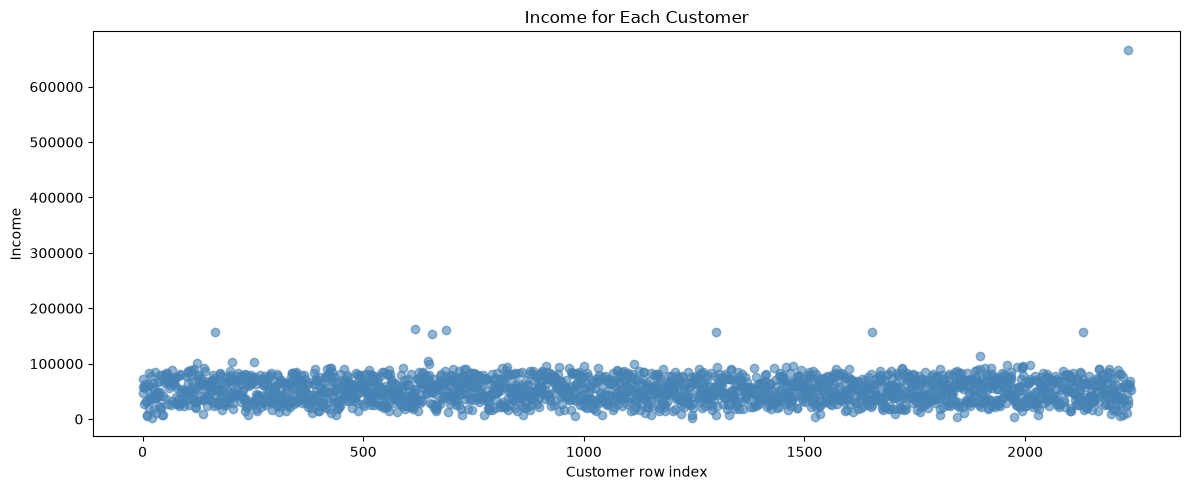

In [321]:
income = marketing_campaign_df['Income'].dropna()

plt.figure(figsize=(12, 5))
plt.scatter(income.index, income, alpha=0.6, color='steelblue')
plt.title('Income for Each Customer')
plt.xlabel('Customer row index')
plt.ylabel('Income')
plt.tight_layout()
plt.show()

## Розрахунок медіани без викидів

In [322]:
income = marketing_campaign_df['Income'].dropna()
q1, q3 = income.quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

income_without_outliers = income[income.between(lower_bound, upper_bound)]
marketing_campaign_clean_df = marketing_campaign_df.copy()

print(f'Викидів, не врахованих під час розрахунку медіани: {len(income) - len(income_without_outliers)}')
print(f'Рядків у робочому DataFrame: {len(marketing_campaign_clean_df)}')

Викидів, не врахованих під час розрахунку медіани: 8
Рядків у робочому DataFrame: 2240


In [323]:
income_mode = income_without_outliers.mode().iloc[0]
income_median = income_without_outliers.median()
income_mean = income_without_outliers.mean()

print(f'Мода: {income_mode}')
print(f'Медіана: {income_median:.2f}')
print(f'Середнє: {income_mean:.2f}')

Мода: 7500.0
Медіана: 51301.00
Середнє: 51633.64


In [324]:
marketing_campaign_clean_df['Income'] = (
    marketing_campaign_clean_df['Income'].fillna(income_median)
)

In [325]:
marketing_campaign_clean_df['Income'].isna().sum()

np.int64(0)

Середнє і медіана дуже близькі, тому заповнюємо медіаною.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [326]:
marketing_campaign_categorical_df = marketing_campaign_df.select_dtypes(include=['string'])
marketing_campaign_categorical_df

,Education,Marital_Status,Dt_Customer
0,Graduation,Single,04-09-2012
1,Graduation,Single,08-03-2014
2,Graduation,Together,21-08-2013
3,Graduation,Together,10-02-2014
4,PhD,Married,19-01-2014
...,...,...,...
2235,Graduation,Married,13-06-2013
2236,PhD,Together,10-06-2014
2237,Graduation,Divorced,25-01-2014
2238,Master,Together,24-01-2014


In [327]:
print(marketing_campaign_categorical_df['Education'].unique())
print(marketing_campaign_categorical_df['Marital_Status'].unique())

<StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str
<StringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str


Ми створимо нову ознаку, що міститиме кількість днів, протягом яких кожен клієнт співпрацює з компанією. Її буде обчислено від дати реєстрації клієнта до поточної дати.

In [328]:
if 'Dt_Customer' in marketing_campaign_clean_df.columns:
    customer_dates = pd.to_datetime(
        marketing_campaign_clean_df['Dt_Customer'],
        format='%d-%m-%Y'
    )
    marketing_campaign_clean_df['Customer_Tenure_Days'] = (
        pd.Timestamp.today().normalize() - customer_dates
    ).dt.days
    marketing_campaign_clean_df = marketing_campaign_clean_df.drop(
        columns=['Dt_Customer']
    )

Для колонок Education та Marital_Status використаємо OneHotEncoder, який створює окрему бінарну ознаку для кожної категорії.

In [329]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_categories = encoder.fit_transform(
    marketing_campaign_clean_df[['Education', 'Marital_Status']]
)

encoded_categories_df = pd.DataFrame(
    encoded_categories,
    columns=encoder.get_feature_names_out(['Education', 'Marital_Status']),
    index=marketing_campaign_clean_df.index
)

marketing_campaign_prepared_df = pd.concat(
    [marketing_campaign_clean_df, encoded_categories_df],
    axis=1
).drop(columns=['Education', 'Marital_Status'])

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [330]:
X = marketing_campaign_prepared_df.select_dtypes(include='number').drop(
    columns=['ID'], errors='ignore'
)

kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels = kmeans.fit_predict(X)

In [331]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.54


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

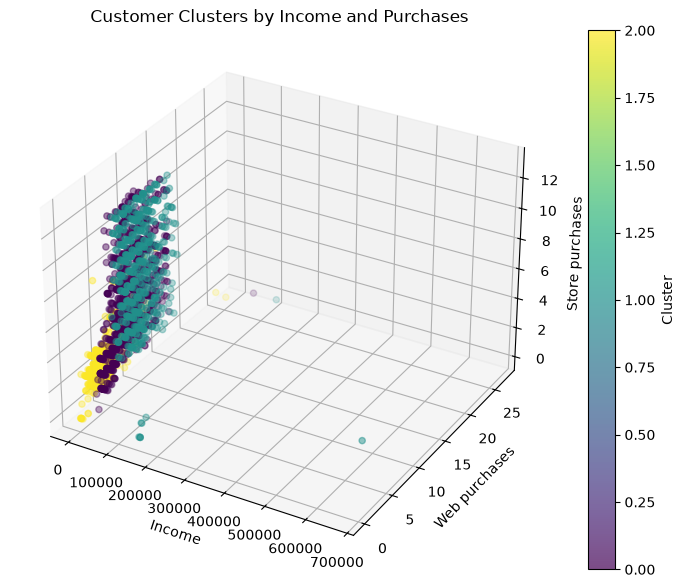

,Income,NumWebPurchases,NumStorePurchases
Cluster,,,
0,54159.69,4.89,6.41
1,79448.16,5.37,8.37
2,28991.10,2.21,3.11


In [332]:
plot_data = X[['Income', 'NumWebPurchases', 'NumStorePurchases']].copy()
plot_data['Cluster'] = labels

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    plot_data['Income'],
    plot_data['NumWebPurchases'],
    plot_data['NumStorePurchases'],
    c=plot_data['Cluster'],
    cmap='viridis',
    alpha=0.7
)
ax.set_xlabel('Income')
ax.set_ylabel('Web purchases')
ax.set_zlabel('Store purchases')
ax.set_title('Customer Clusters by Income and Purchases')
fig.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

cluster_summary = plot_data.groupby('Cluster').mean().round(2)
display(cluster_summary)

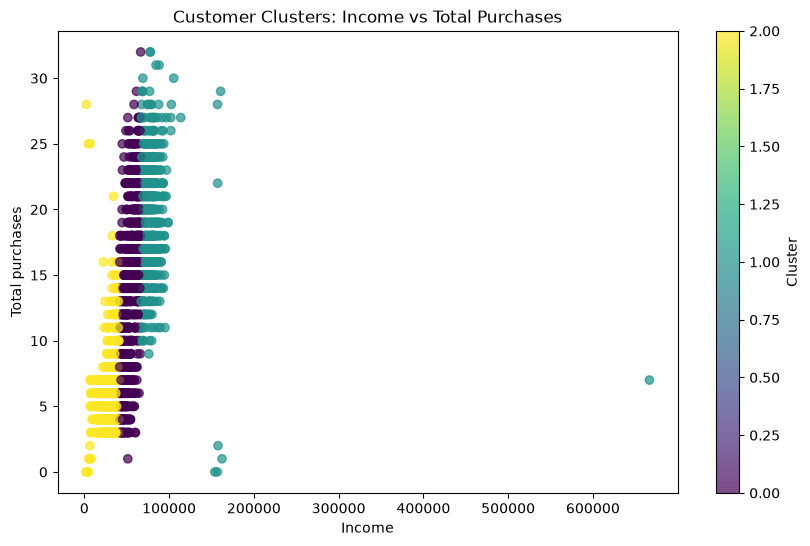

In [333]:
plot_data['TotalPurchases'] = (
    X['NumWebPurchases']
    + X['NumCatalogPurchases']
    + X['NumStorePurchases']
)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    plot_data['Income'],
    plot_data['TotalPurchases'],
    c=plot_data['Cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.xlabel('Income')
plt.ylabel('Total purchases')
plt.title('Customer Clusters: Income vs Total Purchases')
plt.colorbar(scatter, label='Cluster')
plt.show()

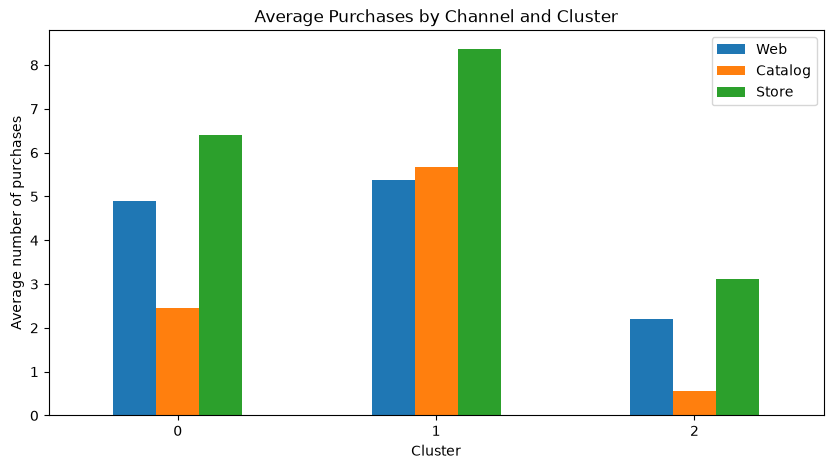

In [334]:
channel_summary = pd.DataFrame({
    'Web': X.groupby(labels)['NumWebPurchases'].mean(),
    'Catalog': X.groupby(labels)['NumCatalogPurchases'].mean(),
    'Store': X.groupby(labels)['NumStorePurchases'].mean()
})

channel_summary.plot(kind='bar', figsize=(10, 5))
plt.title('Average Purchases by Channel and Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average number of purchases')
plt.xticks(rotation=0)
plt.show()

За результатами KMeans було сформовано три кластери клієнтів. Для візуалізації використано дохід клієнта, кількість онлайн-покупок та кількість покупок у фізичному магазині. 

Кластер 2 об’єднує клієнтів із найвищим середнім доходом і високою активністю покупок, тому його можна охарактеризувати як преміальний сегмент. Клієнтів з кластера 1 можна стимулювати знижками.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [335]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [336]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X_scaled_df)

labels_scaled = kmeans.predict(X_scaled_df)

centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X_scaled_df, labels_scaled, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.17


Після масштабування ознак за допомогою StandardScaler силуетний коефіцієнт становить 0.11. Для немасштабованих даних його значення було 0.50.

Отже, у цьому експерименті кластеризація на немасштабованих даних показала краще розділення кластерів.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

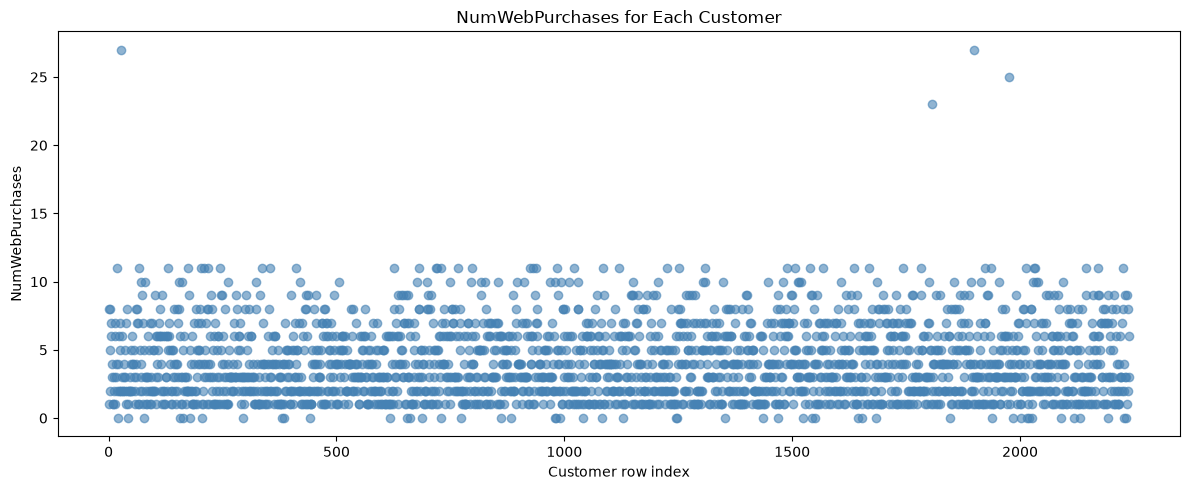

In [337]:
plt.figure(figsize=(12, 5))
plt.scatter(X.index, X['NumWebPurchases'], alpha=0.6, color='steelblue')
plt.title('NumWebPurchases for Each Customer')
plt.xlabel('Customer row index')
plt.ylabel('NumWebPurchases')
plt.tight_layout()
plt.show()

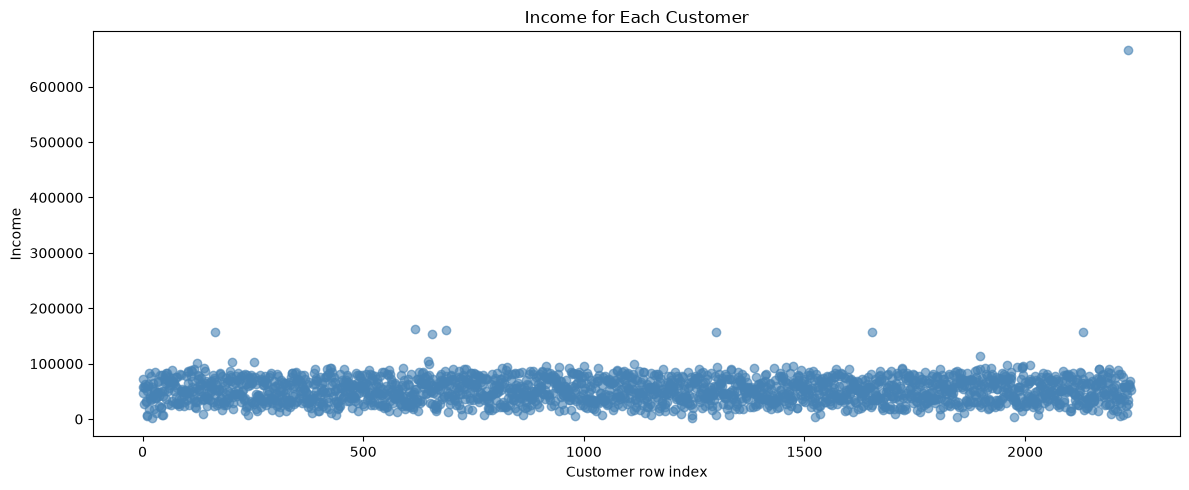

In [338]:
plt.figure(figsize=(12, 5))
plt.scatter(X.index, X['Income'], alpha=0.6, color='steelblue')
plt.title('Income for Each Customer')
plt.xlabel('Customer row index')
plt.ylabel('Income')
plt.tight_layout()
plt.show()

In [339]:
q1, q3 = X['Income'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

income_outliers = ~X['Income'].between(lower_bound, upper_bound)
print(f"Викидів у Income: {income_outliers.sum()}")

X = X.loc[~income_outliers].copy()

Викидів у Income: 8


**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

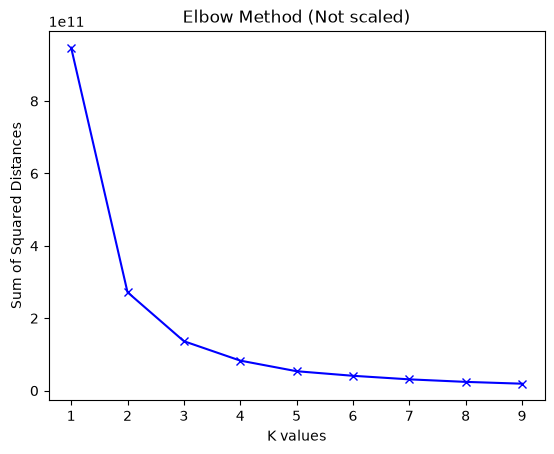

In [340]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method (Not scaled)')
plt.show()

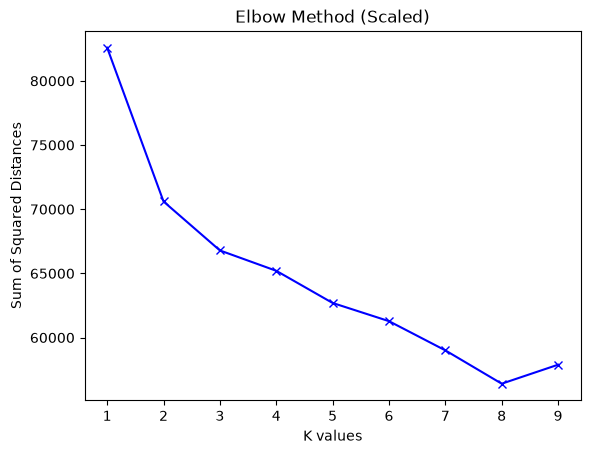

In [341]:
scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(X)
X_scaled_final_df = pd.DataFrame(
    X_scaled_final,
    columns=X.columns,
    index=X.index
)

K = range(1, 10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(
        X_scaled_final_df
    )
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method (Scaled)')
plt.show()

In [342]:
kmeans_final = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_final = kmeans_final.fit_predict(X_scaled_final_df)

silhouette_final = metrics.silhouette_score(X_scaled_final_df, labels_final)
print(f'Silhouette coefficient for 3 clusters: {silhouette_final:.2f}')

Silhouette coefficient for 3 clusters: 0.18


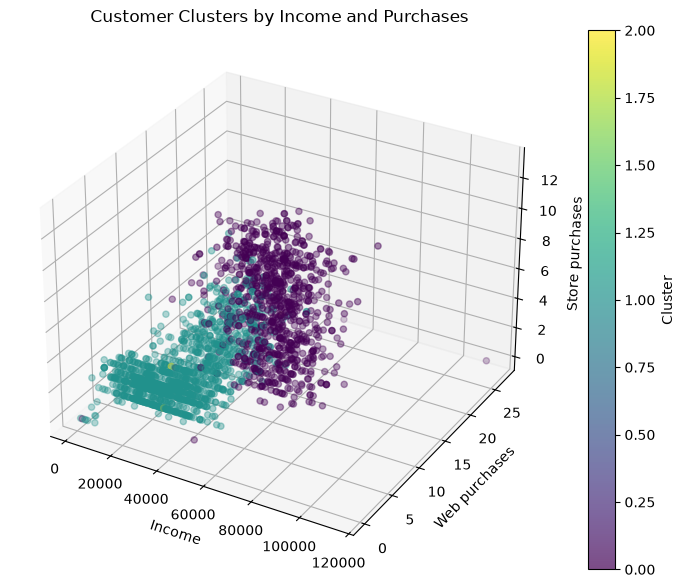

,Income,NumWebPurchases,NumStorePurchases
Cluster,,,
0,71182.43,5.81,8.60
1,38796.77,2.97,3.98
2,43789.00,5.00,4.00


In [343]:
plot_data = X[['Income', 'NumWebPurchases', 'NumStorePurchases']].copy()
plot_data['Cluster'] = labels_final

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    plot_data['Income'],
    plot_data['NumWebPurchases'],
    plot_data['NumStorePurchases'],
    c=plot_data['Cluster'],
    cmap='viridis',
    alpha=0.7
)
ax.set_xlabel('Income')
ax.set_ylabel('Web purchases')
ax.set_zlabel('Store purchases')
ax.set_title('Customer Clusters by Income and Purchases')
fig.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

cluster_summary = plot_data.groupby('Cluster').mean().round(2)
display(cluster_summary)

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

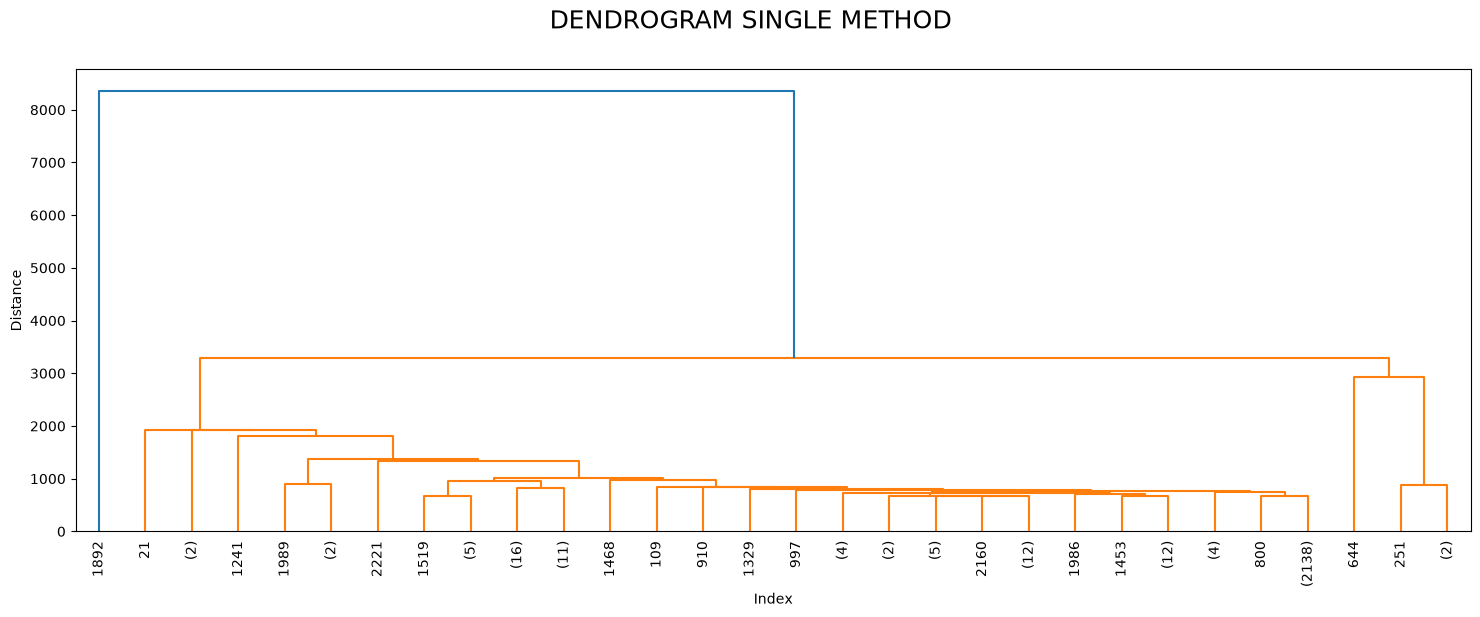

In [354]:
X_hierarchical = X.drop(
    columns=['2_clust', '3_clust', 'TotalPurchases'],
    errors='ignore'
).copy()

dist_sin = linkage(X_hierarchical, method='single')
plt.figure(figsize=(18, 6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle('DENDROGRAM SINGLE METHOD', fontsize=18)
plt.show()

In [355]:
clustered_data = X_hierarchical.copy()
clustered_data['2_clust'] = fcluster(
    dist_sin, 2, criterion='maxclust'
)
clustered_data['3_clust'] = fcluster(
    dist_sin, 3, criterion='maxclust'
)

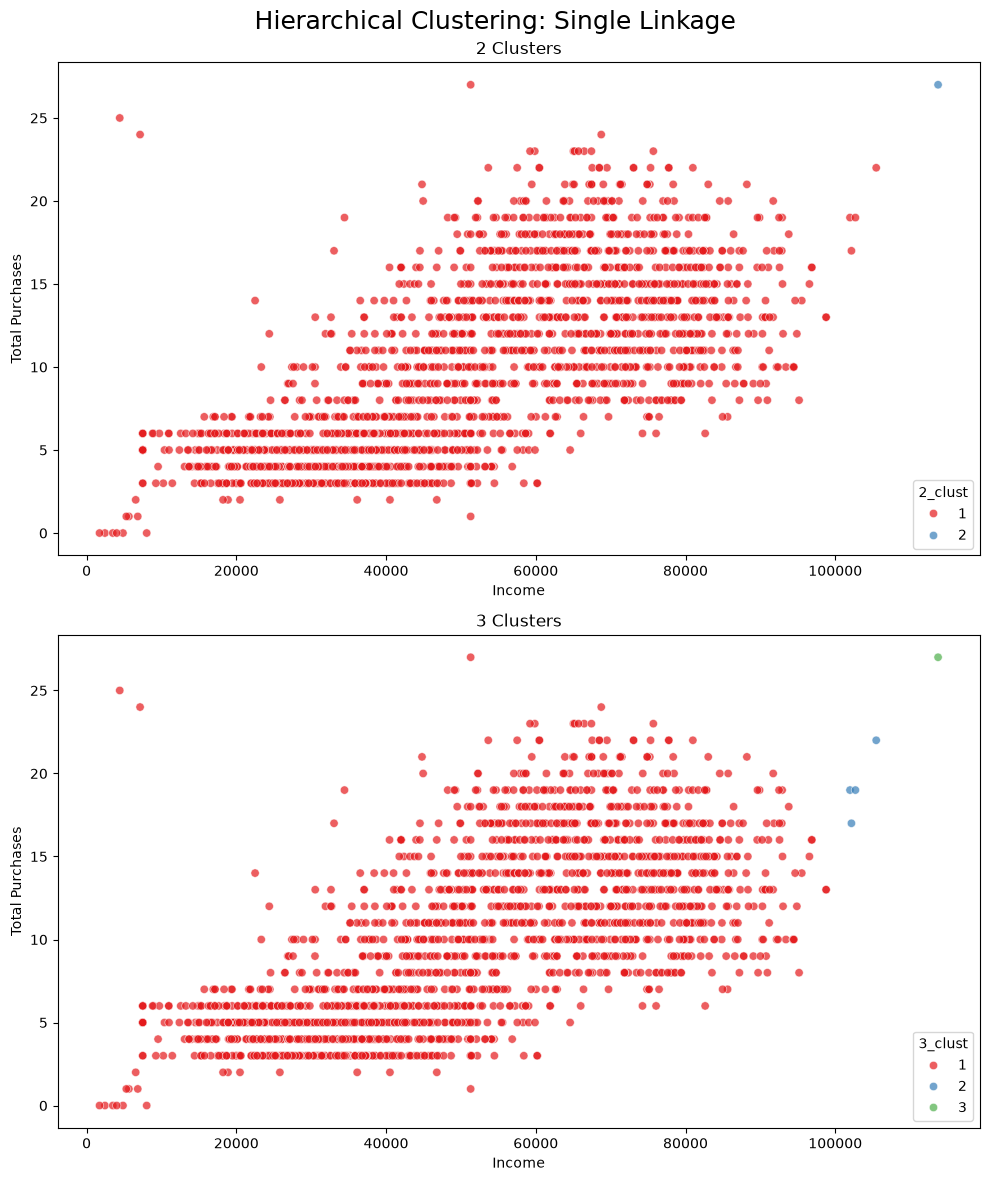

In [352]:
clustered_data['TotalPurchases'] = (
    clustered_data['NumWebPurchases']
    + clustered_data['NumStorePurchases']
)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))
fig.suptitle('Hierarchical Clustering: Single Linkage', fontsize=18)

sns.scatterplot(
    data=clustered_data,
    x='Income',
    y='TotalPurchases',
    hue='2_clust',
    palette='Set1',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('2 Clusters')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Total Purchases')

sns.scatterplot(
    data=clustered_data,
    x='Income',
    y='TotalPurchases',
    hue='3_clust',
    palette='Set1',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('3 Clusters')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Total Purchases')

plt.tight_layout()
plt.show()

За результатом видно, що single linkage сформував один дуже великий кластер і один-два крихітні кластери з крайніми точками. Така кластеризація не дуже вдала.

In [353]:
silhouette_hierarchical = metrics.silhouette_score(
    X_hierarchical,
    clustered_data['3_clust']
)
print(
    f'Silhouette coefficient for hierarchical clustering (3 clusters): '
    f'{silhouette_hierarchical:.2f}'
)

Silhouette coefficient for hierarchical clustering (3 clusters): 0.45


**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

Кількість кластерів: 19
Кількість шумових точок: 1981
Silhouette coefficient: 0.39


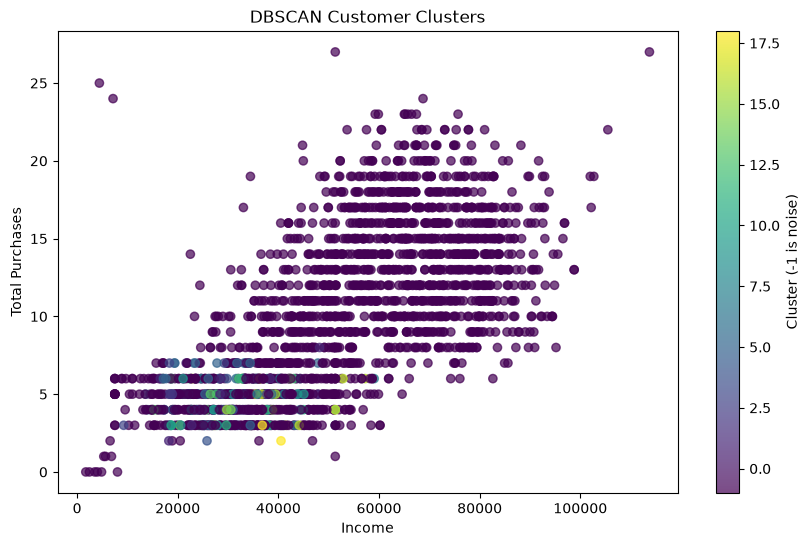

,Income,NumWebPurchases,NumStorePurchases
Cluster,,,
0,47438.40,1.60,2.20
1,30239.20,1.85,2.93
2,20956.00,1.38,3.25
3,27544.67,1.57,2.81
4,31218.90,1.40,2.70
5,29188.15,1.97,3.03
6,34159.25,1.12,2.38
7,37444.35,1.76,3.18
8,25794.20,1.00,2.80


Cluster
-1     1981
 0        5
 1       41
 2        8
 3       21
 4       10
 5       62
 6        8
 7       17
 8        5
 9       15
 10       5
 11       6
 12       8
 13       8
 14       6
 15       9
 16       7
 17       5
 18       5
Name: count, dtype: int64

In [348]:
from sklearn.cluster import DBSCAN

X_dbscan = X_scaled_final_df

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_dbscan)

non_noise_mask = dbscan_labels != -1
cluster_count = len(set(dbscan_labels[non_noise_mask]))
noise_count = (~non_noise_mask).sum()

print(f'Кількість кластерів: {cluster_count}')
print(f'Кількість шумових точок: {noise_count}')

if cluster_count >= 2:
    silhouette_dbscan = metrics.silhouette_score(
        X_dbscan[non_noise_mask],
        dbscan_labels[non_noise_mask]
    )
    print(f'Silhouette coefficient: {silhouette_dbscan:.2f}')

plot_data_dbscan = X[['Income', 'NumWebPurchases', 'NumStorePurchases']].copy()
plot_data_dbscan['TotalPurchases'] = (
    plot_data_dbscan['NumWebPurchases'] + plot_data_dbscan['NumStorePurchases']
)
plot_data_dbscan['Cluster'] = dbscan_labels

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    plot_data_dbscan['Income'],
    plot_data_dbscan['TotalPurchases'],
    c=plot_data_dbscan['Cluster'],
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Income')
plt.ylabel('Total Purchases')
plt.title('DBSCAN Customer Clusters')
plt.colorbar(scatter, label='Cluster (-1 is noise)')
plt.show()

cluster_summary_dbscan = plot_data_dbscan[non_noise_mask].groupby('Cluster')[
    ['Income', 'NumWebPurchases', 'NumStorePurchases']
].mean().round(2)
display(cluster_summary_dbscan)
display(plot_data_dbscan['Cluster'].value_counts().sort_index())

Метод DBSCAN виявив 19 кластерів, а 1981 спостережень було віднесено до шуму. Силуетний коефіцієнт для точок, які увійшли до кластерів, становить 0.39.

Хоча значення силуетного коефіцієнта є прийнятним, результат не є вдалим для основної сегментації клієнтів. Більшість спостережень DBSCAN не відніс до жодного кластера, а знайдені кластери мають невеликий розмір.

Отже, за параметрів `eps=1.5` та `min_samples=5` DBSCAN доцільніше використовувати для виявлення нетипових клієнтів або шумових спостережень. Для поділу всіх клієнтів на кілька великих сегментів практичніше застосовувати KMeans.